In [3]:
import os, zipfile, math
from pathlab import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import sklearn as sk

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, accuracy_score, classification_report, confusion_matrix
)

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Ready")

Ready


In [ ]:
"'Scenario 1'"

In [8]:
PROPERTY_PATH = "property.csv"
if not os.path.exists(PROPERTY_PATH) and os.path.exists("/mnt/data/property.csv"):
    PROPERTY_PATH = "/mnt/data/Property.csv"
    
df_raw = pd.read_csv(PROPERTY_PATH)
print("Raw shape", df_raw.shape)
df_raw.head()

Raw shape (200, 9)


,Land_area,Year_build,Bathrooms,Bedrooms,Driveway_size,Lounge_space,Parking_capacity,Rating,HousePrice
0,9591,26/06/1950,2.0,3,856.0,1713.0,3,5.0,274900
1,8546,25/06/1950,2.0,2,440.0,1121.0,2,5.0,140000
2,10125,30/05/1950,2.0,3,473.0,1279.0,2,6.0,171500
3,7000,07/04/1950,2.0,2,398.0,865.0,1,6.0,112000
4,4438,26/06/1950,NaN,1,420.0,848.0,2,5.0,149000


In [ ]:
"'Clean types'"

In [21]:
df = df_raw.copy()

#Convert Year_build into interger
dt = pd.to_datetime(df["Year_build"], errors="coerce", dayfirst=True)
if dt.notna().sum() > 0:
        df["Year_build"] = dt.dt.year
    
#Numeric conversion
num_cols = ["Land_area", "Year_build", "Bathrooms", "Bedrooms", "Driveway_size", "Lounge_space", "Parking_capacity", "Rating", "HousePrice"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    
#Median imputation
for c in num_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Land_area         200 non-null    int64  
 1   Year_build        200 non-null    float64
 2   Bathrooms         200 non-null    float64
 3   Bedrooms          200 non-null    int64  
 4   Driveway_size     200 non-null    float64
 5   Lounge_space      200 non-null    float64
 6   Parking_capacity  200 non-null    float64
 7   Rating            200 non-null    float64
 8   HousePrice        200 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 14.2 KB


In [ ]:
"'Exploratory Data Analysis'"

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Land_area,200.0,12471.66,21519.459822,1680.0,7919.25,9220.5,11625.0,215245.0
Year_build,200.0,1950.00,0.000000,1950.0,1950.00,1950.0,1950.0,1950.0
Bathrooms,200.0,1.57,0.544594,0.0,1.00,2.0,2.0,3.0
Bedrooms,200.0,2.89,0.788039,1.0,2.00,3.0,3.0,6.0
Driveway_size,200.0,471.82,205.492417,0.0,312.00,463.0,576.0,1053.0
Lounge_space,200.0,1151.69,363.098591,483.0,873.50,1112.0,1399.0,2392.0
Parking_capacity,200.0,1.74,0.710580,0.0,1.00,2.0,2.0,3.0
Rating,200.0,5.47,1.177298,1.0,5.00,5.0,6.0,9.0
HousePrice,200.0,185125.72,77103.969869,61000.0,130750.00,170500.0,221250.0,437154.0


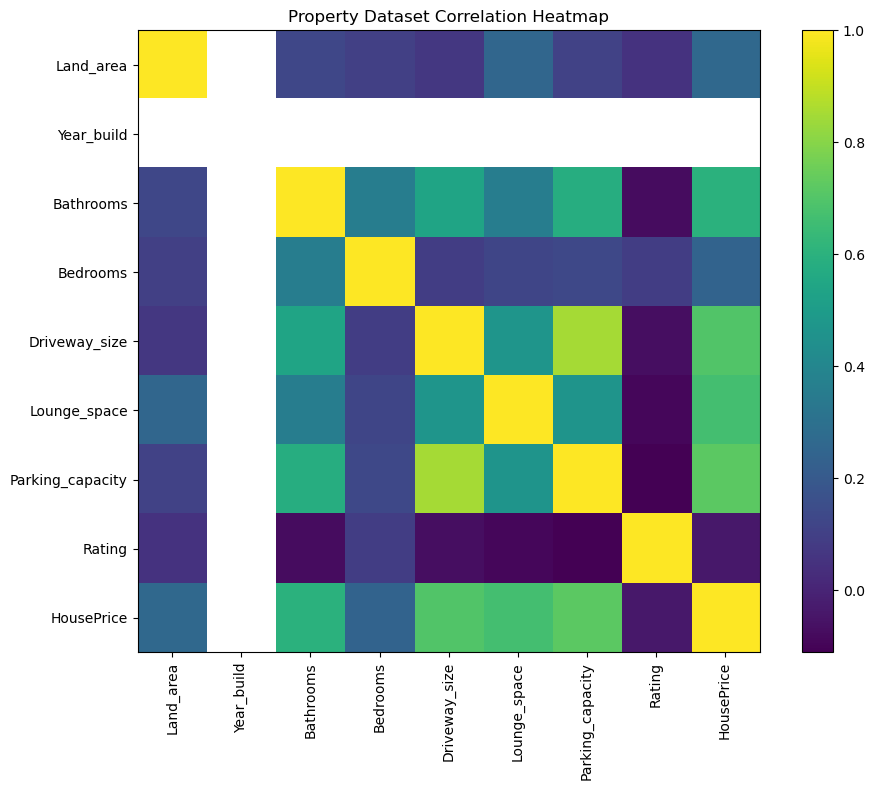

HousePrice          1.000000
Parking_capacity    0.719196
Driveway_size       0.696331
Lounge_space        0.665973
Bathrooms           0.599123
Land_area           0.263914
Bedrooms            0.242902
Rating             -0.039757
Year_build               NaN
Name: HousePrice, dtype: float64

In [24]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Property Dataset Correlation Heatmap")
plt.tight_layout()
plt.show()

corr["HousePrice"].sort_values(ascending=False)

<function matplotlib.pyplot.show(close=None, block=None)>

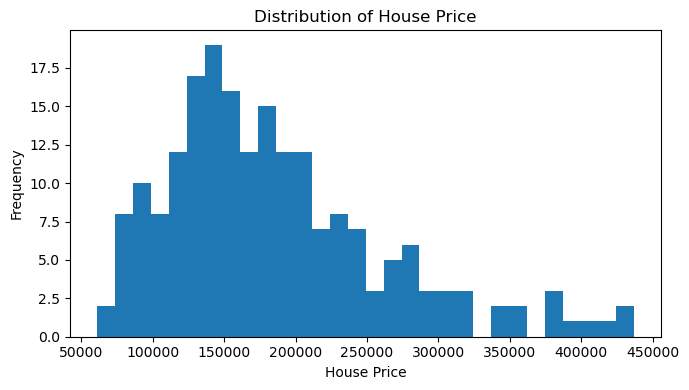

In [25]:
plt.figure(figsize=(7,4))
plt.hist(df["HousePrice"], bins=30)
plt.title("Distribution of House Price")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show

In [ ]:
"'Models'"

In [31]:
PRICE_COL = "HousePrice"
RATING_COL = "Rating"

reg_features = ["Land_area", "Year_build", "Bathrooms", "Bedrooms", "Driveway_size", "Lounge_space", "Parking_capacity", "Rating"]
clf_features = ["Land_area", "Year_build", "Bathrooms", "Bedrooms", "Driveway_size", "Lounge_space", "Parking_capacity"]

x_reg = df[reg_features].copy()
y_reg = df[PRICE_COL].copy()

x_clf = df[clf_features].copy()
y_clf = df[RATING_COL].copy()

print("X_reg:", x_reg.shape, "X_clf:", x_clf.shape)

X_reg: (200, 8) X_clf: (200, 7)


In [ ]:
"'Multiple Linear Regression'"

In [34]:
splits = [(0.30, "70/30"), (0.20, "80/20"), (0.10, "90/10")]
rows = []
for test_size, label in splits:
    x_train, x_test, y_train, y_test = train_test_split(x_reg, y_reg, test_size=test_size, random_state=RANDOM_STATE)
    lr = LinearRegression().fit(x_train, y_train)
    pred = lr.predict(x_test)
    rows.append({
        "split": label,
        "test_size": test_size,
        "r2": r2_score(y_test, pred),
        "mae": mean_absolute_error(y_test, pred),
        "mse": mean_squared_error(y_test, pred, squared=False),
    })
    
lr_results = pd.DataFrame(rows)
lr_results

,split,test_size,r2,mae,mse
0,70/30,0.3,0.615271,36751.412500,50210.261943
1,80/20,0.2,0.645264,29823.309673,40220.091026
2,90/10,0.1,-0.257033,25697.430130,31081.713424


In [ ]:
"'kNN Classification'"

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE)

pipe_knn = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
grid_knn = GridSearchCV(pipe_knn, {"knn__n_neighbors": list(range(1, 21))}, cv=5, scoring="accuracy")
grid_knn.fit(x_train, y_train)

best_knn = grid_knn.best_estimator_
pred_knn = best_knn.predict(x_test)

print("Best k:", grid_knn.best_params_)
print("Test accuracy:", accuracy_score(y_test, pred_knn))
print(confusion_matrix(y_test,pred_knn))

/Users/josephinegeorge/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best k: {'knn__n_neighbors': 11}
Test accuracy: 0.5
[[ 0  2  0  0  0]
 [ 0 17  4  1  0]
 [ 0  5  1  0  0]
 [ 0  4  1  2  0]
 [ 0  2  1  0  0]]


In [43]:
knn_cv = pd.DataFrame(grid_knn.cv_results_)[["param_knn__n_neighbors","mean_test_score","std_test_score"]].copy()
knn_cv.columns = ["k","cv_accuracy_mean","cv_accuracy_std"]
print()
knn_cv.sort_values("cv_accuracy_mean", ascending=False).head(10)

,k,cv_accuracy_mean,cv_accuracy_std
10,11,0.54375,0.031869
13,14,0.54375,0.046771
16,17,0.53750,0.041458
11,12,0.53750,0.053765
9,10,0.53750,0.041458
8,9,0.53125,0.044194
18,19,0.53125,0.034233
19,20,0.53125,0.027951
7,8,0.53125,0.034233
6,7,0.53125,0.052291


In [ ]:
"'SVM Classification'"

In [44]:
pipe_svm = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf"))])
grid_svm = GridSearchCV(pipe_svm, {"svm__C":[0.1,1,10,100], "svm__gamma":["scale",0.01,0.1,1]}, cv=5, scoring="accuracy")
grid_svm.fit(x_train, y_train)

best_svm = grid_svm.best_estimator_
pred_svm = best_svm.predict(x_test)

print("Best params:", grid_svm.best_params_)
print("Test accuracy:", accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))

/Users/josephinegeorge/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}
Test accuracy: 0.55
[[ 0  2  0  0  0]
 [ 0 22  0  0  0]
 [ 0  6  0  0  0]
 [ 0  7  0  0  0]
 [ 0  3  0  0  0]]


In [45]:
comp = pd.DataFrame([
    {"model":"kNN", "best_params": str(grid_knn.best_params_), "test_accuracy": accuracy_score(y_test, pred_knn)},
    {"model":"SVM (RBF)", "best_params": str(grid_svm.best_params_), "test_accuracy": accuracy_score(y_test, pred_svm)},
])
print()
comp

,model,best_params,test_accuracy
0,kNN,{'knn__n_neighbors': 11},0.50
1,SVM (RBF),"{'svm__C': 0.1, 'svm__gamma': 'scale'}",0.55


In [ ]:
"'k-Means, PCA, t-SNE'"

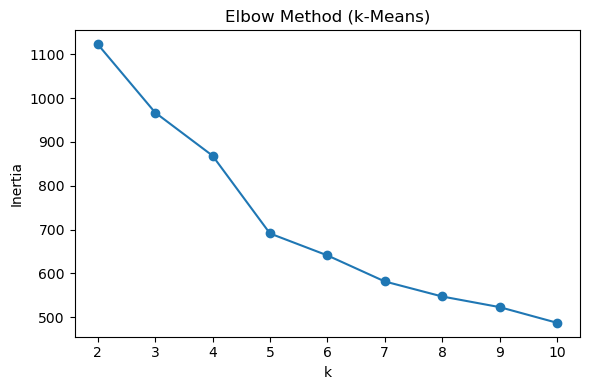

In [47]:
x_cluster = df.select_dtypes(include=[np.number]).copy()
x_scaled = StandardScaler().fit_transform(x_cluster)

Ks = range(2, 11)
inertias = []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto").fit(x_scaled)
    inertias.append(km.inertia_)

elbow = pd.DataFrame({"k": list(Ks), "inertia": inertias})
print()

plt.figure(figsize=(6,4))
plt.plot(list(Ks), inertias, marker="o")
plt.title("Elbow Method (k-Means)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [48]:
BEST_K = 4
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init="auto")
clusters = kmeans.fit_predict(x_scaled)

counts = pd.Series(clusters).value_counts().sort_index().reset_index()
counts.columns = ["cluster_id","count"]
print()
counts

,cluster_id,count
0,0,33
1,1,37
2,2,55
3,3,75


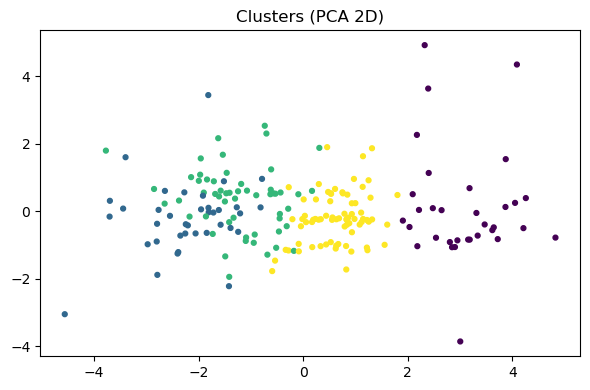

In [49]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Xp = pca.fit_transform(x_scaled)

plt.figure(figsize=(6,4))
plt.scatter(Xp[:,0], Xp[:,1], c=clusters, s=12)
plt.title("Clusters (PCA 2D)")
plt.tight_layout()
plt.show()

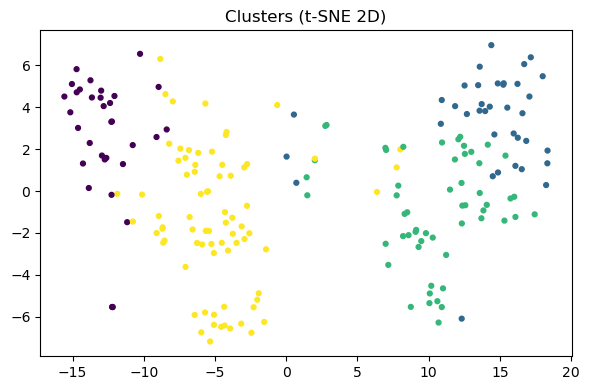

In [50]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, learning_rate="auto", init="pca")
Xt = tsne.fit_transform(x_scaled)

plt.figure(figsize=(6,4))
plt.scatter(Xt[:,0], Xt[:,1], c=clusters, s=12)
plt.title("Clusters (t-SNE 2D)")
plt.tight_layout()
plt.show()

In [ ]:
"'Scenario 2'"

In [55]:
import pathlib

In [60]:
ZIP_PATH = "Employees.zip"
if not os.path.exists(ZIP_PATH) and os.path.exists("/mnt/data/Employees.zip"):
    ZIP_PATH = "/mnt/data/Employees.zip"

#Extract folder 
EMP_DIR = pathlib.Path("Employees_extracted")
EMP_DIR.mkdir(exist_ok=True)

# Find images 
img_paths = []
for root, _, files in os.walk(EMP_DIR):
    for f in files:
        if os.path.splitext(f)[1].lower() in [".png"]:
            img_paths.append(os.path.join(root, f))
img_paths = sorted(img_paths)

print("Images found:", len(img_paths))
img_paths[:5]

Images found: 0


[]

In [59]:
label_df = pd.DataFrame({
    "employee_image": [os.path.basename(p) for p in img_paths],
    "expression_label": [""] * len(img_paths),
    "notes": [""] * len(img_paths),
})
print()
label_df.head()

,employee_image,expression_label,notes
